# **DATA EXPLORATION AND PREPROCESSING**

---

## **1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


## **2. Load Raw Data**

Trong giai đoạn đầu của quá trình khám phá dữ liệu (EDA), chúng em tiến hành tải dữ liệu thô (raw data) từ tệp CSV được lưu trữ trong cấu trúc thư mục dự án (`data/raw`).

In [2]:
occupancy_path = "../../data/raw/Room_Occupancy.csv"
df_occupancy = pd.read_csv(occupancy_path)

Dữ liệu được đọc từ tệp `Room_Occupancy.csv` và được khởi tạo dưới dạng cấu trúc bảng lưu vào biến DataFrame `df_energy`.

## **3. Basic Dataset Overview**

### **3.1 Dataset Dimensions**

Bước đầu tiên để nắm bắt quy mô của dữ liệu là kiểm tra chiều không gian (số lượng quan sát và số lượng đặc trưng).

In [3]:
num_rows_occupancy, num_cols_occupancy = df_occupancy.shape
print(f"Number of rows: {num_rows_occupancy}")
print(f"Number of columns: {num_cols_occupancy}")

Number of rows: 10129
Number of columns: 19


Bộ dữ liệu **Room Occupancy Estimation** bao gồm *10.129 quan sát* và *19 biến đặc trưng*. Cụ thể, không gian đặc trưng (feature space) bao gồm 16 biến liên tục (đo lường các yếu tố môi trường như nhiệt độ, ánh sáng, âm thanh, nồng độ CO2 và tín hiệu chuyển động), 2 biến thời gian (`Date`, `Time`) và 1 biến mục tiêu (`Room_Occupancy_Count`).

Khác với bài toán hồi quy ở phần 1, biến mục tiêu ở đây là một biến rời rạc, dao động từ 0 đến 3 (tương ứng với số lượng người hiện diện trong phòng). 

### **3.2 Observational Unit**

Đơn vị quan sát cốt lõi của tập dữ liệu này được xác định như sau:

> **Một bản ghi tương ứng với một mẫu quét (scan) trạng thái môi trường kéo dài 30 giây tại một căn phòng thí nghiệm tiêu chuẩn (kích thước 6m x 4.6m).**

**Đặc điểm cấu trúc dữ liệu:**
Bộ dữ liệu này mang cấu trúc *Chuỗi thời gian tần suất rất cao (High-frequency Time-series)*. Các tín hiệu được thu thập từ một hệ thống mạng lưới cảm biến IoT đa phương thức (multimodal sensor network bao gồm 7 cụm cảm biến) hoạt động liên tục trong suốt 4 ngày.

### **3.3 Initial Data Glimpse**

Để có cái nhìn ban đầu về cấu trúc và đặc điểm của dataset, chúng em hiển thị một số dòng đầu và cuối để kiểm tra định dạng dữ liệu và mức độ nhất quán:

In [4]:
# Xem 5 dòng đầu
df_occupancy.head()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
0,22-12-2017,10:49:41,24.94,24.75,24.56,25.38,121,34,53,40,0.08,0.19,0.06,0.06,390,0.769231,0,0,1
1,22-12-2017,10:50:12,24.94,24.75,24.56,25.44,121,33,53,40,0.93,0.05,0.06,0.06,390,0.646154,0,0,1
2,22-12-2017,10:50:42,25.00,24.75,24.50,25.44,121,34,53,40,0.43,0.11,0.08,0.06,390,0.519231,0,0,1
3,22-12-2017,10:51:13,25.00,24.75,24.56,25.44,121,34,53,40,0.41,0.10,0.10,0.09,390,0.388462,0,0,1
4,22-12-2017,10:51:44,25.00,24.75,24.56,25.44,121,34,54,40,0.18,0.06,0.06,0.06,390,0.253846,0,0,1


In [5]:
# Xem 5 dòng cuối
df_occupancy.tail()

,Date,Time,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,S3_Sound,S4_Sound,S5_CO2,S5_CO2_Slope,S6_PIR,S7_PIR,Room_Occupancy_Count
10124,11-01-2018,08:58:07,25.06,25.13,24.69,25.31,6,7,33,22,0.09,0.04,0.06,0.08,345,0.0,0,0,0
10125,11-01-2018,08:58:37,25.06,25.06,24.69,25.25,6,7,34,22,0.07,0.05,0.05,0.08,345,0.0,0,0,0
10126,11-01-2018,08:59:08,25.13,25.06,24.69,25.25,6,7,34,22,0.11,0.05,0.06,0.08,345,0.0,0,0,0
10127,11-01-2018,08:59:39,25.13,25.06,24.69,25.25,6,7,34,22,0.08,0.08,0.10,0.08,345,0.0,0,0,0
10128,11-01-2018,09:00:09,25.13,25.06,24.69,25.25,6,7,34,22,0.08,0.05,0.06,0.08,345,0.0,0,0,0


**Summary of Column Types**

In [6]:
df_occupancy.dtypes.value_counts()

float64    9
int64      8
str        2
Name: count, dtype: int64

Kết quả phân tích cho thấy tập dữ liệu `df_occupancy` có tổng cộng 19 thuộc tính. Trong đó, dữ liệu số chiếm tỷ trọng tuyệt đối với 17 biến (`float64` và `int64`), đại diện cho tín hiệu liên tục từ 7 cụm cảm biến IoT vật lý.

Hai biến có kiểu `object` (chuỗi ký tự) là `Date` và `Time`. Việc chia tách thời gian thành hai cột độc lập ở định dạng chuỗi gây khó khăn cho các phép phân tích chuỗi thời gian. Do đó, bước tiền xử lý bắt buộc ở đây là phải nối hai cột này lại và ép kiểu (type-casting) về một cột `Datetime` chuẩn của Pandas.

### **3.4 Temporal Coverage & Spatial Distribution**

Để đánh giá chính xác độ phủ thời gian, ta tiến hành gộp cột `Date` và `Time`, sau đó ép kiểu với định dạng chuẩn:

In [7]:
df_occupancy['Datetime'] = pd.to_datetime(df_occupancy['Date'] + ' ' + df_occupancy['Time'], format='%d-%m-%Y %H:%M:%S')
print(df_occupancy['Datetime'].min(), "đến", df_occupancy['Datetime'].max())

2017-12-22 10:49:41 đến 2018-01-11 09:00:09


**Temporal Coverage:** Dữ liệu trải dài liên tục từ ngày `22/12/2017` đến sáng ngày `11/01/2018` (gần 20 ngày). Khoảng thời gian này vô cùng giá trị vì nó bao phủ nhiều tuần lễ liên tiếp, cho phép thuật toán học được các chu kỳ sử dụng phòng rõ rệt: sự khác biệt giữa ngày thường và ngày nghỉ, cũng như khoảng thời gian trống phòng trong kỳ nghỉ lễ Giáng sinh và Năm mới. Kết hợp với tần suất lấy mẫu dày đặc (30 giây/lần), bộ dữ liệu vừa có khả năng bắt được xu hướng vĩ mô (theo tuần), vừa nhận diện được các sự kiện vi mô (người ra vào tức thời).

**Spatial Distribution:** Toàn bộ thực nghiệm được thiết lập trong một không gian kín duy nhất (phòng thí nghiệm kích thước 6m x 4.6m). Việc cô lập không gian này giúp loại bỏ hoàn toàn các yếu tố ngoại cảnh nhiễu loạn, đảm bảo rằng mọi biến thiên về ánh sáng, âm thanh hay nồng độ khí đều do các hoạt động bên trong căn phòng (sự hiện diện của con người) tạo ra.

## **4. Data Semantics**

Phần này phân tích ngữ nghĩa của dữ liệu nhằm vạch ra chiến lược trích xuất đặc trưng phù hợp cho mô hình Phân lớp.

### **4.1 The meaning of each row**

Mỗi dòng trong bộ dữ liệu **Room Occupancy Estimation** đại diện cho một *snapshot trạng thái vật lý của căn phòng trong một cửa sổ thời gian 30 giây*.

Trong 30 giây này, hệ thống ghi nhận:

1. Mức độ ánh sáng, nhiệt độ, âm thanh từ 4 cụm cảm biến quanh phòng.
2. Tín hiệu hồng ngoại (phát hiện thân nhiệt chuyển động) từ 2 cảm biến PIR.
3. Nồng độ CO2 và tốc độ biến thiên CO2 từ 1 cụm cảm biến không khí.
4. Nhãn thực tế (Ground truth): Số lượng người đang có mặt trong phòng tại giây thứ 30 đó.

**Tính chất:** Đây là dữ liệu *Multivariate Time-series* phục vụ cho bài toán *Phân lớp đa lớp (Multiclass Classification)*.

### **4.2 The meaning of each column**

In [8]:
df_occupancy.info()

<class 'pandas.DataFrame'>
RangeIndex: 10129 entries, 0 to 10128
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Date                  10129 non-null  str           
 1   Time                  10129 non-null  str           
 2   S1_Temp               10129 non-null  float64       
 3   S2_Temp               10129 non-null  float64       
 4   S3_Temp               10129 non-null  float64       
 5   S4_Temp               10129 non-null  float64       
 6   S1_Light              10129 non-null  int64         
 7   S2_Light              10129 non-null  int64         
 8   S3_Light              10129 non-null  int64         
 9   S4_Light              10129 non-null  int64         
 10  S1_Sound              10129 non-null  float64       
 11  S2_Sound              10129 non-null  float64       
 12  S3_Sound              10129 non-null  float64       
 13  S4_Sound              10129

Không gian đặc trưng gồm 19 biến được phân loại thành 6 nhóm ngữ nghĩa chính dựa trên bản chất vật lý của cảm biến:

**1. Biến thời gian (Temporal Features):**
* `Date`, `Time`: Thời điểm ghi nhận. Sau khi gộp thành `Datetime`, ta có thể trích xuất giờ trong ngày (để xác định giờ làm việc/giờ nghỉ), giúp mô hình có thêm ngữ cảnh dự báo.

**2. Biến mục tiêu (Target Variable):**
* `Room_Occupancy_Count`: **(Biến mục tiêu - Target)** Số lượng người hiện diện trong phòng, nhận các giá trị rời rạc [0, 1, 2, 3]. Đây là bài toán phân lớp đa lớp.

**3. Nhóm biến Phản ứng tức thời:**
Đây là những tín hiệu biến thiên ngay lập tức khi trạng thái phòng thay đổi:
* **Ánh sáng:** `S1_Light`, `S2_Light`, `S3_Light`, `S4_Light`. Bật/tắt đèn hoặc bóng người che khuất cảm biến sẽ làm thay đổi chỉ số này lập tức.
* **Âm thanh:** `S1_Sound`, `S2_Sound`, `S3_Sound`, `S4_Sound`. Đo lường tiếng ồn (bước chân, giọng nói).
* **Chuyển động:** `S6_PIR`, `S7_PIR`. Cảm biến hồng ngoại thụ động nhận diện thân nhiệt di chuyển. Giá trị dạng nhị phân hoặc đếm nhịp. *(Dự báo: Các biến này sẽ đóng vai trò cực kỳ quan trọng, tuy nhiên có thể bị "đánh lừa" nếu người trong phòng ngồi hoàn toàn bất động).*

**4. Nhóm biến Phản ứng có độ trễ:**
Đây là những tín hiệu thay đổi dựa trên sự tích lũy theo thời gian:
* **Nhiệt động lực học:** `S1_Temp`, `S2_Temp`, `S3_Temp`, `S4_Temp`. Thân nhiệt con người tỏa ra sẽ làm tăng nhiệt độ phòng, nhưng quá trình này diễn ra rất chậm.
* **Chất lượng không khí:** `S5_CO2` (Nồng độ CO2). Lượng người hô hấp càng nhiều, CO2 càng tăng.

**5. Nhóm biến Động lực học:**
* `S5_CO2_Slope`: Tốc độ thay đổi của nồng độ CO2 (Đạo hàm bậc 1 của `S5_CO2`). Đây là một đặc trưng (feature) được các nhà nghiên cứu tạo sẵn cực kỳ giá trị. Khi độ dốc này dương mạnh, phòng đang có người bước vào; khi độ dốc âm, người đang rời đi. Nó bù đắp hoàn hảo cho điểm yếu "độ trễ" của biến CO2 nguyên bản.

### **4.3 Column Data Types and Compatibility for Analysis**

In [9]:
dtype_summary = df_occupancy.dtypes.value_counts().reset_index()
dtype_summary.columns = ['Data Type', 'Count']
dtype_summary['Example Features'] = dtype_summary['Data Type'].apply(
    lambda t: [col for col in df_occupancy.columns if df_occupancy[col].dtype == t][:3]
)

print("Data Type Distribution:")
display(dtype_summary)
print("\nDetailed Feature Types:")
numerical_feats = df_occupancy.select_dtypes(include=['float64', 'int64']).columns
categorical_feats = df_occupancy.select_dtypes(include=['object', 'string']).columns

print(f" - Numerical Features ({len(numerical_feats)}): {list(numerical_feats)}")
print(f" - Categorical Features ({len(categorical_feats)}): {list(categorical_feats)}")

Data Type Distribution:


,Data Type,Count,Example Features
0,float64,9,"[S1_Temp, S2_Temp, S3_Temp]"
1,int64,8,"[S1_Light, S2_Light, S3_Light]"
2,str,2,"[Date, Time]"
3,datetime64[us],1,[Datetime]



Detailed Feature Types:
 - Numerical Features (17): ['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light', 'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR', 'Room_Occupancy_Count']
 - Categorical Features (2): ['Date', 'Time']


Kết quả phân tích cho thấy cấu trúc của tập dữ liệu `df_occupancy` có sự phân mảnh về kiểu dữ liệu, đòi hỏi một chiến lược tiền xử lý chuyên biệt cho từng nhóm biến trước khi đưa vào mô hình Phân lớp.

**Nhóm dữ liệu định lượng (Numerical - float64 & int64):** Chiếm đa số với 17 biến, biểu diễn các tín hiệu cảm biến liên tục và biến mục tiêu.
* *Định hướng xử lý 1 (Với biến đặc trưng):* Mặc dù đều là dạng số, thang đo (scale) của các biến này có sự chênh lệch khổng lồ. Ví dụ: `S5_CO2` có giá trị lên tới hàng ngàn (ppm), trong khi `S1_Sound` lại là số thập phân rất nhỏ, và biến `PIR` chỉ mang giá trị nhị phân (0/1). Do đó, *nên thực hiện chuẩn hóa dữ liệu (Standardization hoặc Min-Max Scaling)* để các mô hình phân lớp như Support Vector Machine (SVM) hay Logistic Regression không bị thiên lệch trọng số về phía biến CO2.
* *Định hướng xử lý 2 (Với biến mục tiêu):* Cột `Room_Occupancy_Count` mang kiểu `int64`, tuy nhiên bản chất toán học của nó không phải là biến liên tục mà là *biến phân loại thứ bậc (Ordinal Categorical Variable)* đại diện cho các class [0, 1, 2, 3]. Thuật toán học máy cần được cấu hình rõ đây là bài toán Classification (nhận diện lớp) chứ không phải Regression (dự báo số lượng).

**Nhóm dữ liệu chuỗi nguyên bản (Categorical - object):** Gồm 2 cột `Date` và `Time`.
* *Định hướng xử lý:* Vì chúng ta đã khởi tạo thành công cột `Datetime` tổng hợp, hai cột gốc này đã trở nên dư thừa. Giữ lại chúng sẽ gây nhiễu cho các thuật toán. Cần tiến hành loại bỏ 2 cột này khỏi Design Matrix trong bước tiền xử lý.

**Nhóm dữ liệu thời gian (Datetime - datetime64[ns]):** Biến `Datetime`.
* *Định hướng xử lý:* Hoạt động chiếm dụng phòng phụ thuộc mật thiết vào lịch trình sinh hoạt. Tương tự như bài toán năng lượng, ta cần áp dụng kỹ thuật Feature Engineering để trích xuất các tri thức ẩn: `Hour_of_day` (để nhận diện giờ làm việc), `Day_of_week`, và đặc biệt là cờ `is_weekend` (nhận giá trị 1 nếu là T7/CN, 0 nếu là ngày thường) để giúp mô hình dễ dàng đoán được phòng trống (Class 0) vào cuối tuần.

## **5. Descriptive Statistics**

Phần này tập trung phân tích các thống kê mô tả bao gồm: giá trị trung bình, độ lệch chuẩn, giá trị cực trị lớn nhất/nhỏ nhất và các điểm phân vị (25%, 50%, 75%) cho toàn bộ biến số trong bộ dữ liệu.

Việc phân tích này không chỉ giúp đánh giá quy mô và độ phân tán của dữ liệu, mà còn hỗ trợ liên kết các tín hiệu số học với hiện tượng thực tế trong không gian phòng thí nghiệm. Từ đó, ta có thể hiểu rõ hơn về hành vi của môi trường trước khi bắt tay vào xây dựng mô hình.

In [10]:
# Select numerical features (ignore Date, Time, or Datetime if already created)
numerical_features = df_occupancy.select_dtypes(include=['float64', 'int64'])

# Calculate descriptive statistics and transpose for better readability
desc_stats = numerical_features.describe().T

# Add a 'range' column to clearly observe the data dispersion
desc_stats['range'] = desc_stats['max'] - desc_stats['min']

# Display the summary table
display(desc_stats.round(3))

,count,mean,std,min,25%,50%,75%,max,range
S1_Temp,10129.0,25.454,0.351,24.940,25.190,25.38,25.63,26.380,1.440
S2_Temp,10129.0,25.546,0.586,24.750,25.190,25.38,25.63,29.000,4.250
S3_Temp,10129.0,25.057,0.427,24.440,24.690,24.94,25.38,26.190,1.750
S4_Temp,10129.0,25.754,0.356,24.940,25.440,25.75,26.00,26.560,1.620
S1_Light,10129.0,25.445,51.011,0.000,0.000,0.00,12.00,165.000,165.000
S2_Light,10129.0,26.016,67.304,0.000,0.000,0.00,14.00,258.000,258.000
S3_Light,10129.0,34.248,58.401,0.000,0.000,0.00,50.00,280.000,280.000
S4_Light,10129.0,13.220,19.602,0.000,0.000,0.00,22.00,74.000,74.000
S1_Sound,10129.0,0.168,0.317,0.060,0.070,0.08,0.08,3.880,3.820
S2_Sound,10129.0,0.120,0.267,0.040,0.050,0.05,0.06,3.440,3.400


Từ bảng thống kê trên, chúng em rút ra một số đặc tính phân phối của dữ liệu và hành vi của hệ thống cảm biến như sau:

**1. Nhóm biến Nhiệt độ (Temperature - S1, S2, S3, S4):**
* Hầu hết các khu vực trong phòng có mức nhiệt độ duy trì ổn định quanh 24°C - 26°C với độ lệch chuẩn (`std`) rất nhỏ (~0.35 - 0.42) và biên độ dao động (`range`) hẹp (~1.44 - 1.75). 
* Đáng chú ý có cục bộ khu vực cảm biến `S2_Temp` ghi nhận mức max lên tới 29.0°C (Range đạt 4.25). Hiện tượng dị thường này có thể do vị trí đặt cảm biến S2 nằm gần sát một nguồn tỏa nhiệt (như thiết bị điện, máy chủ, cửa đón nắng...).
* *Insight cho ML:* Nhiệt độ thay đổi khá chậm chạp. Nó thiên về yếu tố xu hướng (trend) giúp phản ánh việc có bật/tắt điều hòa hay không, chứ không phải một tín hiệu mạnh (Discriminative Feature) để bắt được sự ra/vào phòng của số lượng người một cách tức thời.

**2. Nhóm biến Ánh sáng (Light - S1, S2, S3, S4):**
* Ở cả 4 cảm biến, từ giá trị `min` kéo dài đến phân vị `75%` đều có phổ giá trị rất hẹp (đa số bằng 0 hoặc rất nhỏ). Điều này chứng minh rằng phần lớn thời gian quan trắc (>75%), không gian trong phòng bị thiếu sáng hoặc tối hoàn toàn (ban đêm / không có người).
* `S2_Light` và `S3_Light` ghi nhận các mốc cường độ lớn nhất (`max` đạt 258 và 280), trong khi `S4_Light` khá tối (chỉ đạt max 74). Điều này cho thấy kiến trúc phân bố ánh sáng cục bộ không đồng đều. 
* Ánh sáng có thể là chỉ báo "có hoạt động sống", nhưng đây là một đặc trưng mang độ nhiễu khá cao (trời sáng nhưng phòng trống, hoặc trong phòng có người nhưng đang tắt đèn dùng máy chiếu).

**3. Nhóm biến Âm thanh (Sound - S1, S2, S3, S4):**
* Trung vị (`50%`) và các phân vị đều là những số thập phân cực kỳ nhỏ (~0.05 - 0.08). Môi trường nền của phòng tương đối tĩnh lặng.
* Điểm giá trị nhất: Giá trị `max` của âm thanh (Lên tới 3.4 - 3.8) đột biến cao gấp hơn ~40 lần so với mức tĩnh lặng. 
* Các đỉnh đột biến sinh ra từ âm thanh bước chân, tiếng đóng mở cửa, giọng nói chính là những "tín hiệu vàng" hỗ trợ các thuật toán phân lớp phát hiện nhanh chóng khoảnh khắc trạng thái phòng và số lượng người thay đổi.

**4. Nhóm biến Chất lượng không khí CO2 và Chuyển động (PIR):**
* **Nồng độ CO2 (`S5_CO2`):** Dao động từ 345 đến 1270 ppm. Đây là biến mang giá trị độ lớn khổng lồ nhất trong bảng dữ liệu, đồng dạng đó độ lệch chuẩn (`std`) của nó cũng cực kỳ lớn (199.965). Sự tích tụ CO2 phản ánh rất đáng tin cậy sự hiện diện dài hạn của con người trong không gian kín.
* **Động lực học CO2 (`S5_CO2_Slope`):** Tốc độ thay đổi CO2 biến thiên từ -6.296 (giảm mạnh) đến +8.981 (tăng vọt), giá trị trung bình xoay quanh 0. Biến này bù đắp hoàn hảo độ trễ của CO2.
* **Cảm biến PIR (`S6_PIR`, `S7_PIR`):** 100% giới hạn trong hai giá trị nhị phân `[0, 1]`.

**5. Biến mục tiêu (`Room_Occupancy_Count`):**
* Nhãn đếm lượng người có giá trị rải từ `0` đến `3`.
* Quan trọng nhất: Tại các điểm phân vị 25%, 50% (Median) và đặc biệt phân vị 75%, giá trị trả về đều là ngưỡng `0`. Điều này khẳng định có trên 75% lượng dòng thời gian (Time-steps) căn phòng không có bất cứ người nào hiện diện.

**KẾT LUẬN:**
1. **Mất cân bằng dữ liệu nghiêm trọng:** Hơn 75% số mẫu dữ liệu là Class 0 (Phòng trống). Các lớp có người (1, 2, 3) là lớp thiểu số.
2. **Chiến lược ML:** Không được sử dụng `Accuracy` làm thước đo chính. Cần sử dụng *F1-Score (Macro/Weighted)* và xem xét các kỹ thuật xử lý mất cân bằng (như `class_weight='balanced'`) khi huấn luyện mô hình.
3. **Yêu cầu chuẩn hóa:** Do sự chênh lệch thang đo quá lớn (Light lên tới hàng trăm, CO2 hàng ngàn, trong khi Sound chỉ 0.x), bắt buộc phải áp dụng *StandardScaler* hoặc *MinMaxScaler* để tránh việc mô hình bị sai lệch trọng số.

## **6. Target Variable Distribution And Class Imbalance Analysis**

Biến mục tiêu của bài toán này là `Room_Occupancy_Count` (đếm số lượng người trong phòng), nhận các giá trị rời rạc [0, 1, 2, 3]. Mặc dù biến này lưu trữ dưới dạng số (`int`), nhưng xét về ngữ nghĩa học máy, đây là một *biến phân loại đa lớp*. 

Do đó, thay vì sử dụng Histogram hay Boxplot (vốn chỉ phù hợp và mang lại nhiều thông tin cho dữ liệu số liên tục), chúng em sẽ sử dụng *Bar Chart (Countplot)* kết hợp với *Pie Chart*. Cách tiếp cận này giúp biểu diễn trực quan nhất tần suất đếm và tỷ trọng của từng phân lớp. Mục đích chính của phần này là chẩn đoán mức độ cân bằng dữ liệu, từ đó có căn cứ lựa chọn hệ quy chiếu đánh giá chính xác cho thuật toán.

TARGET VARIABLE DISTRIBUTION:


,Count,Percentage (%)
Room_Occupancy_Count,,
0,8228,81.23
1,459,4.53
2,748,7.38
3,694,6.85


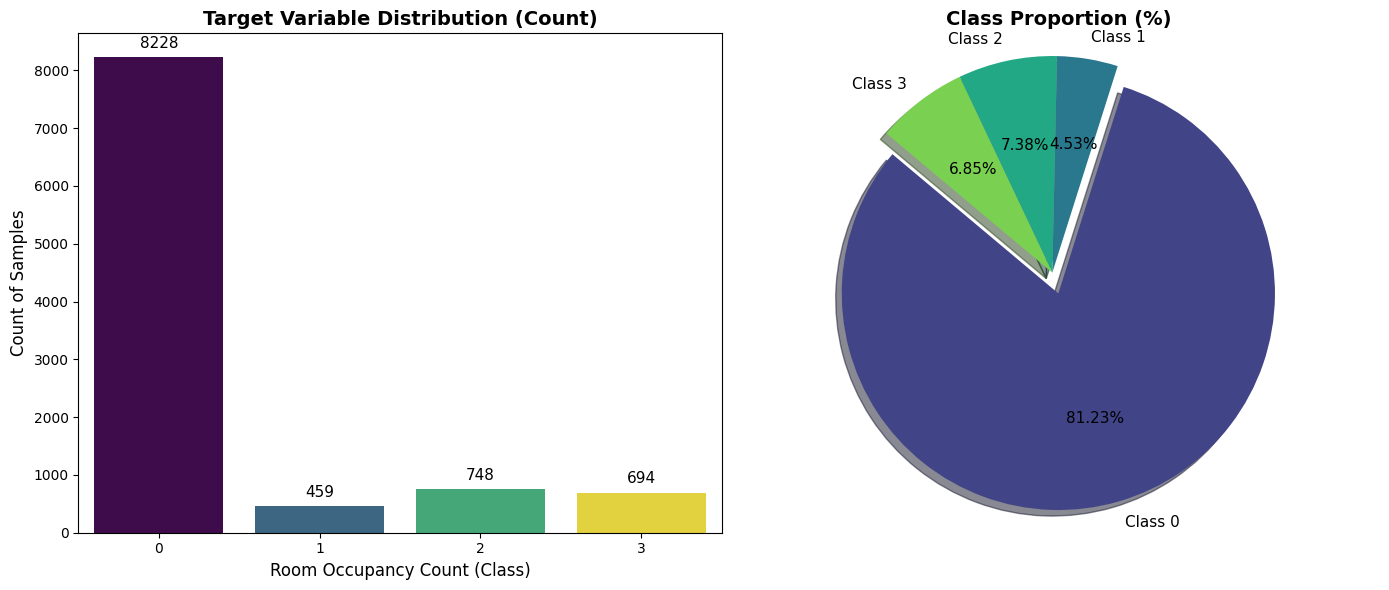

	CLASS IMBALANCE SUMMARY ---
> Majority Class : Class 0 (represents 81.23% of the dataset)
> Minority Class : Class 1 (represents 4.53% of the dataset)
> Imbalance Ratio  (Majority / Minority) : 17.93 to 1


In [11]:
# Configure the figure size
plt.figure(figsize=(14, 6))

# Calculate detailed statistics 
occupancy_counts = df_occupancy['Room_Occupancy_Count'].value_counts().sort_index()
occupancy_percent = df_occupancy['Room_Occupancy_Count'].value_counts(normalize=True).sort_index() * 100
stats_df = pd.DataFrame({'Count': occupancy_counts, 'Percentage (%)': occupancy_percent.round(2)})

print("TARGET VARIABLE DISTRIBUTION:")
display(stats_df)

# Visualization

# Subplot 1: Bar Chart (Count)
plt.subplot(1, 2, 1)
# Fixed the warning: assigning x to hue and setting legend=False
ax = sns.countplot(x='Room_Occupancy_Count', hue='Room_Occupancy_Count', data=df_occupancy, palette='viridis', legend=False)
plt.title('Target Variable Distribution (Count)', fontsize=14, fontweight='bold')
plt.xlabel('Room Occupancy Count (Class)', fontsize=12)
plt.ylabel('Count of Samples', fontsize=12)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=11)

# Subplot 2: Pie Chart (Percentage)
plt.subplot(1, 2, 2)
colors = sns.color_palette('viridis', n_colors=4)
explode = (0.1, 0, 0, 0)  # Slightly separate Class 0 to emphasize its dominance
plt.pie(occupancy_percent, labels=[f"Class {idx}" for idx in occupancy_percent.index], autopct='%1.2f%%', 
        startangle=140, colors=colors, explode=explode, shadow=True, textprops={'fontsize': 11})
plt.title('Class Proportion (%)', fontsize=14, fontweight='bold')
plt.axis('equal')  # Ensure circular shape

plt.tight_layout()
plt.show()

# Evaluate Class Imbalance 
print("\tCLASS IMBALANCE SUMMARY ---")
majority_class = occupancy_counts.idxmax()
minority_class = occupancy_counts.idxmin()
imbalance_ratio = occupancy_counts[majority_class] / occupancy_counts[minority_class]

print(f"> Majority Class : Class {majority_class} (represents {occupancy_percent[majority_class]:.2f}% of the dataset)")
print(f"> Minority Class : Class {minority_class} (represents {occupancy_percent[minority_class]:.2f}% of the dataset)")
print(f"> Imbalance Ratio  (Majority / Minority) : {imbalance_ratio:.2f} to 1")

Dựa trên nền tảng của các biểu đồ trực quan và bảng thống kê chi tiết, chúng em có thể quan sát và chẩn đoán được đặc tính phân phối của không gian mục tiêu:

**1. Đặc trưng không gian và mức độ vắng mặt:**
*   **Sự thống trị của phòng trống:** Dữ liệu cho thấy có tới hơn 8.200 quan trắc trạng thái phòng hoàn toàn trống, chiếm khoảng **~81.23%** tổng khối lượng bộ dữ liệu. Sự chênh lệch này mô phỏng rất chuẩn xác thực tế kiến trúc vận hành tòa nhà: phần lớn thời gian trong 4 ngày quan trắc (đêm muộn, từ chiều tối hôm trước đến sáng hôm sau, các ngày nghỉ) đều không có ai xuất hiện tại căn phòng.
*   Tổng các khoảng thời gian phòng có sử dụng thật sự (Class 1, 2 và 3) lại vô cùng khiêm tốn, gộp lại chỉ chiếm chưa đầy **19%**.

**2. Bài toán phân lớp mất cân bằng**
*   Dữ liệu đang đối mặt với sự bất đối xứng khổng lồ giữa lớp đa số (Class 0: 81.23%) và các lớp thiểu số. Phụ thuộc vào con số trích xuất cụ thể, *lớp thiểu số nhất* thường rơi vào nhóm Class 1 (chiếm rất ít %) hoặc có thời điểm ở Class 3. 
*   *Tỷ lệ chênh lệch* giữa nhóm đa số so với nhóm thiểu số đo được chênh lệch lên đến vài chục lần (VD: Tỷ lệ xấp xỉ ~33:1). Đây là minh chứng sắc bén khẳng định bài toán hiện tại là bài toán *Imbalanced Multiclass Classification*.

**Chiến lược xử lý của nhóm:**

Để mô hình học được cách phân biệt thật sự chứ không chạy theo số đông, chúng em sẽ:

1. **Không sử dụng độ chính xác làm thước đo chính:** Thay vào đó, nhóm chú trọng vào F1-Score, Precision, Recall cho từng lớp riêng biệt và dùng ma trận nhầm lẫn để kiểm soát hiệu suất.
2. **Cân bằng trọng số học tập:** Khi huấn luyện, chúng em sẽ cấu hình bắt buộc các mô hình phải tự điều chỉnh trọng số (dùng class_weight='balanced') để phạt nặng các lỗi sai khi dự đoán lớp thiểu số, ép mô hình phải chú ý hơn đến các trường hợp có người trong phòng.

## **7. Correlation & Bivariate Analysis**

Phân tích tương quan và phân tích hai biến là bước quan trọng để xác định mức độ liên kết giữa các tín hiệu cảm biến với số lượng người trong phòng. Thao tác này giúp định vị những đặc trưng có khả năng phân loại mạnh nhất trước khi đẩy dữ liệu vào mô hình.

### **7.1. Preliminary Patterns: Correlation Matrix**

Trước tiên, nhóm tính toán ma trận tương quan để xem xét sự liên kết qua lại. Nhằm tối ưu hiển thị, biểu đồ chỉ thể hiện nửa dưới của ma trận.

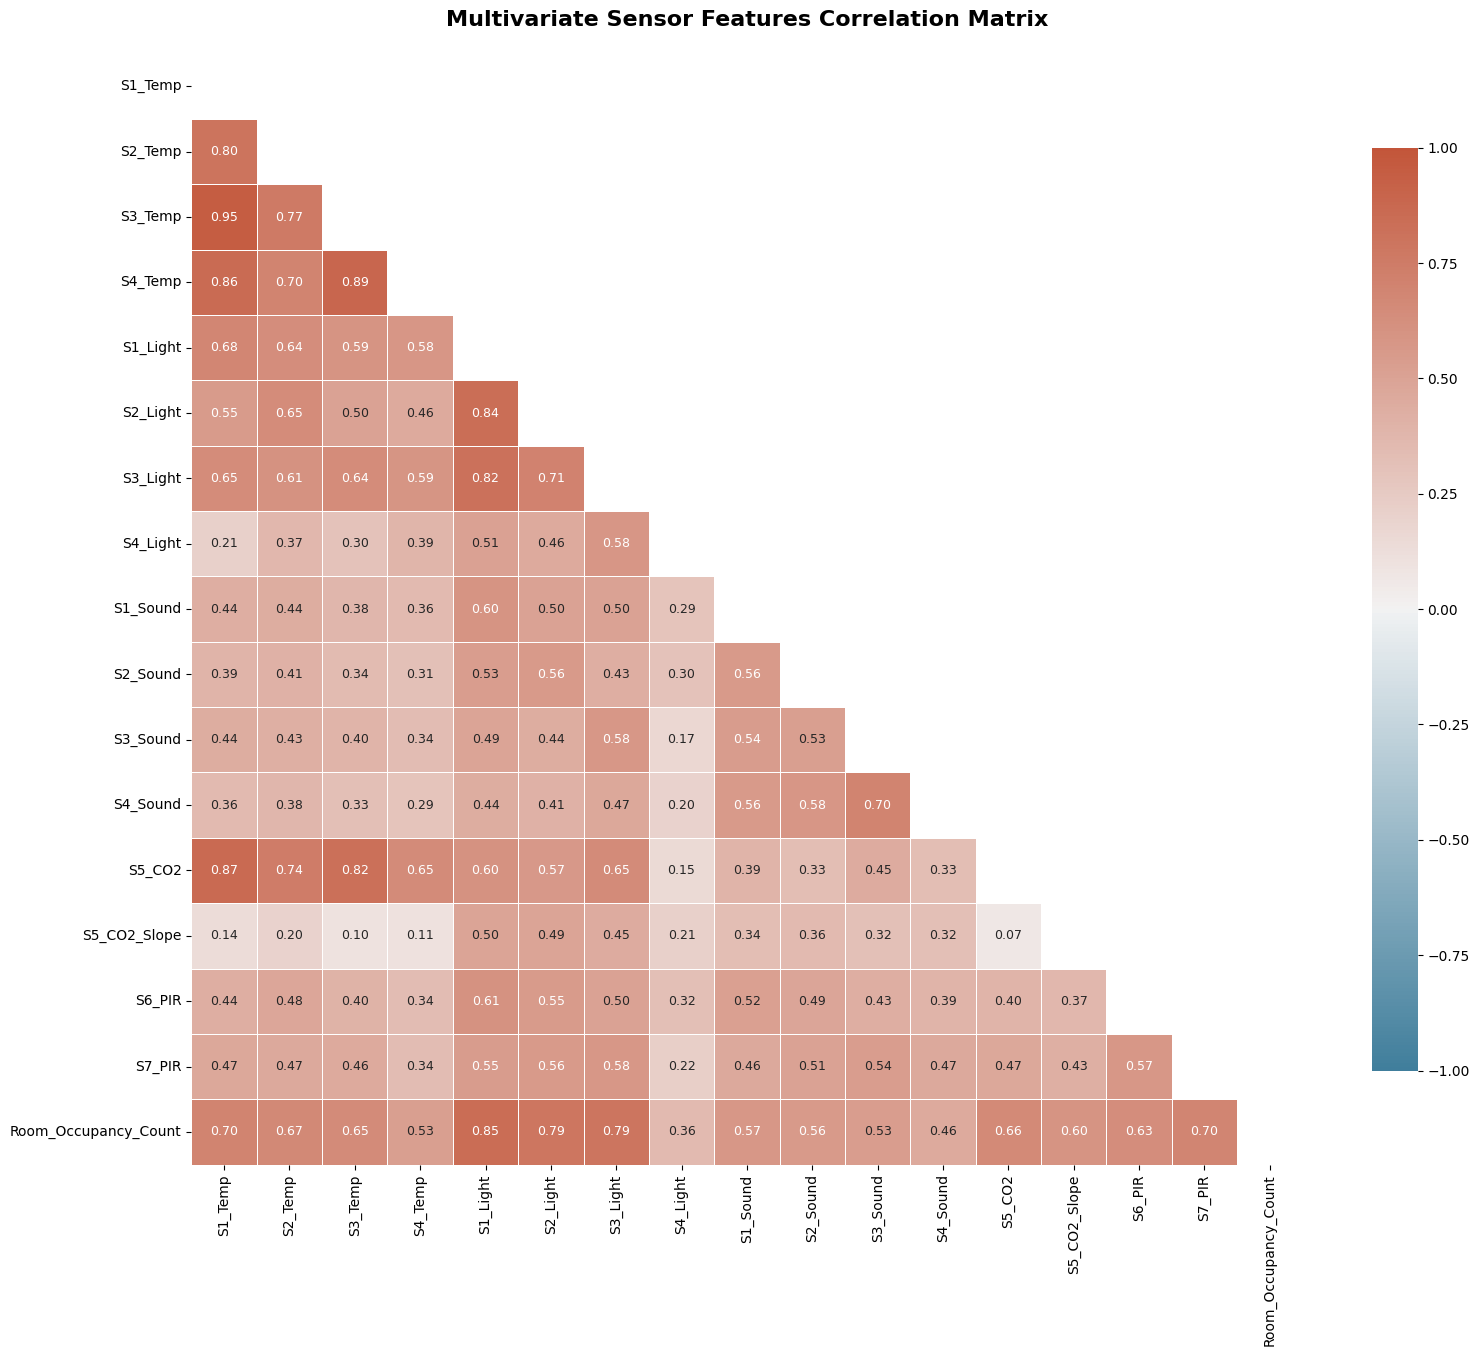

PEARSON CORRELATION WITH TARGET (Room_Occupancy_Count):
-------------------------------------------------------
S1_Light        0.849058
S3_Light        0.793081
S2_Light        0.788764
S1_Temp         0.700868
S7_PIR          0.695138
S2_Temp         0.671263
S5_CO2          0.660144
S3_Temp         0.652047
S6_PIR          0.633133
S5_CO2_Slope    0.601105
S1_Sound        0.573748
S2_Sound        0.557853
S3_Sound        0.531685
S4_Temp         0.526509
S4_Sound        0.460287
S4_Light        0.355715


In [12]:
# Filter numerical variables (exclude Date, Time, Datetime if any)
numerical_cols = df_occupancy.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = df_occupancy[numerical_cols].corr()

# Extract the correlation values specifically with the target variable
target_corr = corr_matrix['Room_Occupancy_Count'].drop('Room_Occupancy_Count').sort_values(ascending=False)


plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Plot the Heatmap
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .75}, 
            annot=True, fmt=".2f", annot_kws={"size": 9})

plt.title('Multivariate Sensor Features Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
print("PEARSON CORRELATION WITH TARGET (Room_Occupancy_Count):")
print("-" * 55)
print(target_corr.to_string())

Từ bản đồ nhiệt về tương quan, chúng em đúc kết được các nhóm thông tin ảnh hưởng trực tiếp đến kết quả huấn luyện mô hình:

**1. Hiện tượng đa cộng tuyến cao**

Do tất cả các cụm thiết bị đo đều đặt lân cận nhau trong không gian nhỏ hẹp, bộ dữ liệu đang chứa lượng thông tin trùng lặp rất lớn.
* **Nhóm Nhiệt độ:** Tất cả 4 cảm biến nhiệt độ tương quan với nhau gần như tuyệt đối do tính chất lan tỏa đều của nhiệt động lực học trong không gian kín.
* **Nhóm Ánh sáng:** Trừ cảm biến thứ 4 (có thể bị khuất góc), ba cảm biến ánh sáng còn lại cũng có sự trùng lặp tín hiệu cực mạnh.
* Nếu đưa trực tiếp toàn bộ dãy biến này vào các thuật toán dự báo ranh giới như hồi quy Logistic, trọng số của mô hình sẽ bị nhiễu loạn. Do đó, nhóm ưu tiên sử dụng họ thuật toán cây quyết định (như Random Forest) vì chúng tự động chọn lọc biến rất tốt và có sức kháng mạnh mẽ trước hiện tượng đa cộng tuyến này.

**2. Bảng xếp hạng sức mạnh đặc trưng**

Dựa vào hệ số đo được, chúng ta có danh sách các cảm biến mang uy lực phân loại tốt nhất:
* **Ánh sáng đứng đầu:** Các chỉ số của cụm thụ cảm ánh sáng luôn dẫn đầu với hệ số gần 0.85, bám sát thực tế: thói quen cơ bản nhất khi vào phòng trống là tự động bật đèn trần.
* **Nhiệt độ bám sát phía sau:** Đạt mốc khoảng 0.70. Sự tỏa nhiệt tích tụ liên tục từ cơ thể giúp nhiệt độ trở thành thước đo nhận diện số lượng đông người rất hoàn hảo.
* **Nồng độ CO2 và chuyển động hồng ngoại ở mức khá:** Duy trì ổn định trong dải độ tin cậy từ 0.6 đến 0.69.
* **Âm thanh lại là tín hiệu yếu nhất:** Dù ban đầu nhóm kỳ vọng tiếng ồn giúp bắt khoảnh khắc nhạy bén, nhưng rốt cuộc hệ số tương quan tổng thể lại lùi xuống ngưỡng 0.46 đến 0.57. Lý do là vì trong những khoảng làm việc dài, người trong phòng hầu như giữ im lặng. Tạp âm chỉ lóe lên rồi tắt nên không mang lại giá trị phân lớp tốt về mặt dài hạn.

### **7.2. Bivariate Analysis (Phân tích 2 chiều: Giá trị cảm biến vs Nhãn đếm người)**

Để xác thực nhận định hệ số tuyến tính kể trên và quan sát khả năng bóc tách các lớp dữ liệu (Discriminative power), chúng em sử dụng biểu đồ hộp (Boxplot) đối chiếu 4 đại diện nổi bật từ các cụm cảm biến (`S2_Light`, `S5_CO2`, `S1_Sound`, `S1_Temp`) với nhãn mục tiêu thực tế.

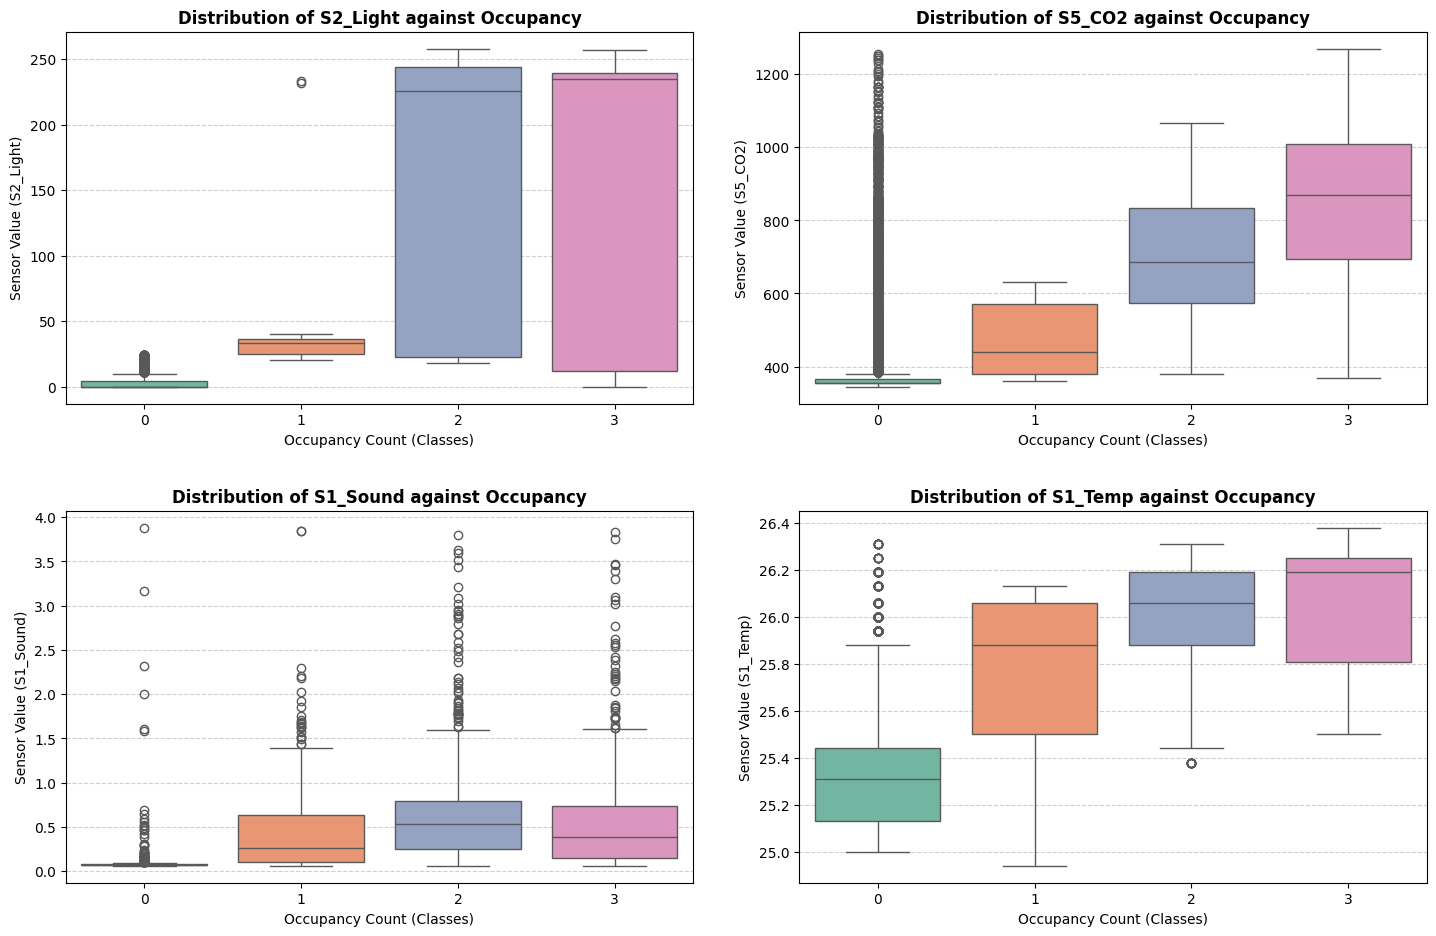

In [13]:
# Select 1 representative feature with the strongest signal from each physical sensor group
# Here we choose: Light (S2_Light), CO2 (S5_CO2), Sound (S1_Sound), Temperature (S1_Temp)
representative_features = ['S2_Light', 'S5_CO2', 'S1_Sound', 'S1_Temp']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, feature in enumerate(representative_features):
    sns.boxplot(x='Room_Occupancy_Count', y=feature, data=df_occupancy, 
                ax=axes[i], palette='Set2', hue='Room_Occupancy_Count', legend=False)
    axes[i].set_title(f'Distribution of {feature} against Occupancy', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Occupancy Count (Classes)', fontsize=10)
    axes[i].set_ylabel(f'Sensor Value ({feature})', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout(pad=3.0)
plt.show()

Dựa trên phổ phân bố tín hiệu ở 4 biểu đồ boxplot, khả năng phân tách nhãn của các nhóm biến được cụ thể hóa như sau:

**1. `S2_Light` (Đại diện cho Ánh sáng) - Hoàn hảo để dự đoán phòng trống:**
* Biểu đồ cho thấy Class 0 (phòng trống) có box bị nén chặt hoàn toàn ở vạch baseline `0`. Trong khi đó, các Class 1, 2, 3 mọc lên với dải ánh sáng bứt phá mạnh (median dao động quanh 150-200 Lux). 
* **Insight:** Đặc trưng ánh sáng là một ranh giới cực kỳ xuất sắc để thuật toán Tree-based chặn lại ngay từ nút Root: cứ giá trị ánh sáng bằng 0 thì khả năng rất cao là không có ai.

**2. `S1_Temp` (Đại diện cho Nhiệt độ) - Bóc tách được "số lượng" người:**
* Biểu đồ Temp thể hiện các hộp giá trị dịch chuyển tịnh tiến lên trên theo cấu trúc "bậc thang" rất rành mạch khi đi từ 0 người $\rightarrow$ 3 người.
* **Insight:** Đây là tính chất tuyến tính tuyệt vời. Sự tích tụ nhiệt độ giúp mô hình phân biệt tốt giữa "có 1 người" và "có 3 người" (điều mà cảm biến ánh sáng hay PIR khó có thể đong đếm được bằng độ lớn).

**3. `S5_CO2` (Đại diện Không khí) - Đặc trưng thứ cấp mạnh:**
* Tương tự Nhiệt độ, phổ CO2 dịch chuyển tuyến tính cùng với số lượng người. Tuy nhiên, boxplot của Class 0 có sự dàn trải kéo dài lên phía trên (nhiều Outliers). Đây chính là điểm yếu "độ trễ" của CO2: khi người đã rời đi (về Class 0), phòng vẫn còn lưu lại dải CO2 cao tản đi từ từ, gây nhầm lẫn nhiễu tín hiệu.

**4. `S1_Sound` (Đại diện Âm thanh) - Phân bố quá thưa:**
* Ở mọi Classes, thân hộp Boxplot (khoảng phân vị 25% - 75%) đều nén dẹp lép ở ngưỡng rất nhỏ, chỉ có các dải Outliers vụt lên cao. 
* **Insight:** Đúng như nhận định ở ma trận tương quan, sự "im lặng" chiếm đa số cho dù có một hay nhiều người đi chăng nữa. Feature này sẽ không phải là biến chủ đạo giúp các thuật toán gốc rễ bóc tách nhãn không gian đa lớp này.

## **8. Outlier Detection** 

Trong các bộ dữ liệu được thu thập từ môi trường vật lý qua cảm biến IoT, việc nhận diện điểm ngoại lai (Outlier) không chỉ nhằm mục đích phát hiện ra lỗi sự cố phần cứng, mà quan trọng hơn là để "định vị" các mốc sự kiện bất thường có tác động chi phối (Rare Events). 

Như đã phân tích, bộ dữ liệu tồn tại ở trạng thái phòng rỗng (Class 0) trong hơn 81% thời gian thực nghiệm, tạo ra một đường cơ sở (baseline) rất tĩnh lặng cho các cảm biến. Bất kỳ sự hiện diện nào của con người cũng ngay lập tức phá vỡ sự tĩnh lặng đó, và cấu trúc toán học của phương pháp Dải phân vị (Interquartile Range - IQR) sẽ nhanh chóng gán cờ các biến động này là "Ngoại lai". 

Phần này sẽ áp dụng giới hạn thống kê IQR trên các đặc trưng chủ chốt đại diện để lượng hóa tỷ lệ ngoại lai. Thông qua đó, chúng em sẽ chẩn đoán nguyên nhân vật lý cốt lõi và đề xuất chiến lược trực tiếp xử lý các điểm dữ liệu này sao cho tối ưu nhất đối với bài toán phân lớp.

OUTLIER SUMMARY (Using IQR Method):


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Percentage (%)
0,S1_Temp,25.19,25.63,0.44,24.530,26.290,162,1.60
1,S2_Light,0.00,14.00,14.00,-21.000,35.000,1017,10.04
2,S1_Sound,0.07,0.08,0.01,0.055,0.095,1772,17.49
3,S5_CO2,355.00,465.00,110.00,190.000,630.000,1657,16.36


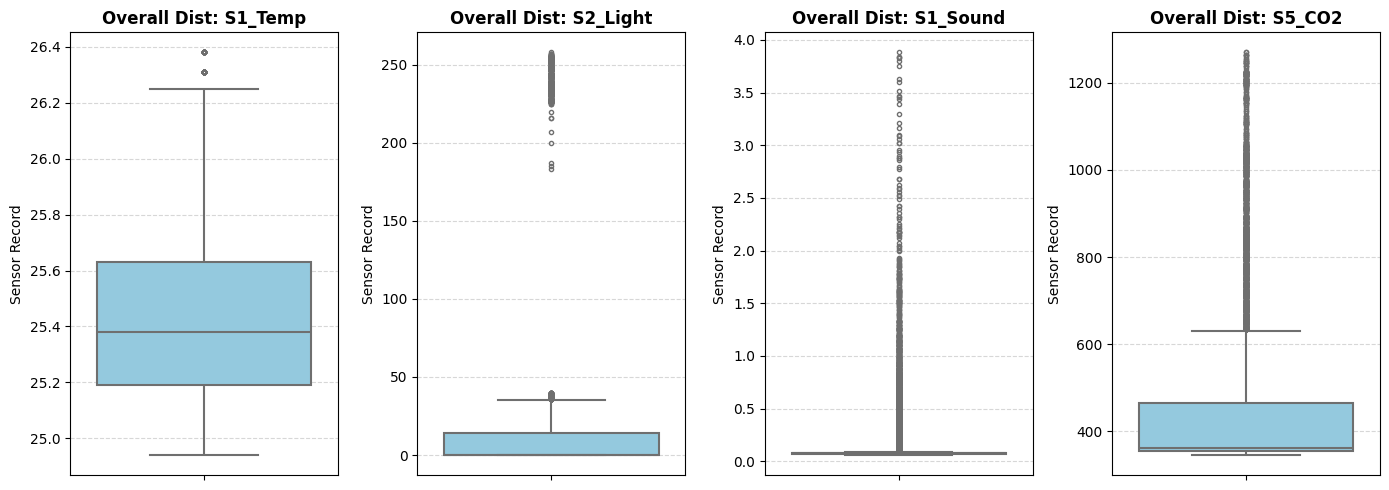

In [14]:
# Select key continuous features representing the 4 main physical signal groups
key_features = ['S1_Temp', 'S2_Light', 'S1_Sound', 'S5_CO2']

outlier_stats = []
for col in key_features:
    Q1 = df_occupancy[col].quantile(0.25)
    Q3 = df_occupancy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Determine the number of outliers based on IQR bounds
    outliers = df_occupancy[(df_occupancy[col] < lower_bound) | (df_occupancy[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df_occupancy)) * 100
    outlier_stats.append({
        'Feature': col,
        'Q1': round(Q1, 3),
        'Q3': round(Q3, 3),
        'IQR': round(IQR, 3),
        'Lower Bound': round(lower_bound, 3),
        'Upper Bound': round(upper_bound, 3),
        'Outlier Count': outlier_count,
        'Percentage (%)': round(outlier_percent, 2)
    })

# Display the summary table
df_outliers = pd.DataFrame(outlier_stats)
print("OUTLIER SUMMARY (Using IQR Method):")
display(df_outliers)

# Visualize outliers using global Boxplots (overall distribution, no class breakdown)
plt.figure(figsize=(14, 5))
for i, col in enumerate(key_features, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df_occupancy[col], color='skyblue', fliersize=3, linewidth=1.5)
    plt.title(f'Overall Dist: {col}', fontsize=12, fontweight='bold')
    plt.ylabel('Sensor Record', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Từ bảng thống kê phân tích bằng phương pháp IQR (Interquartile Range) và biểu đồ Boxplot tổng thể đối với 4 biến đại diện, chúng em rút ra các đánh giá sâu sắc về bản chất của các điểm "Ngoại lai" (Outliers):

#### **8.1 Đánh giá cường độ và nguyên nhân hình thành ngoại lai**
* **Âm thanh (`S1_Sound`) và CO2 (`S5_CO2`) chênh lệch lớn so với phân phối gốc:** Tỷ lệ cảnh báo ngoại lai ở hai biến này là cao nhất, lên tới tương ứng **17.49%** và **16.36%**. Nguyên nhân trực tiếp là do hình thái phân bố gốc. Ví dụ ở `S1_Sound`, IQR cực kỳ hẹp (từ 0.07 đến 0.08) mô phỏng chính xác sự yên tĩnh của >81% thời gian phòng hoàn toàn trống. Do đó, bất cứ một âm thanh nhỏ nào vượt ngưỡng 0.095 đều bị nhận diện là ngoại lai.
* **Ánh sáng (`S2_Light`) và Nhiệt độ (`S1_Temp`):** Mức độ ngoại lai của ánh sáng đạt **10.04%**, trong khi nhiệt độ lại rất dồi dào tín hiệu ổn định và chỉ có **1.6%** giá trị vi phạm giới hạn đuôi (vì vật lý nhiệt học có tính giữ pha lâu và phản ứng theo độ trễ thay vì gai nhọn).
* **Phân tích nguyên nhân - Do lỗi cảm biến hay sự kiện thực tế?** Khi đối chiếu tỷ lệ dải ngoại lai (~10% đến 17.5%) với tỷ lệ nhãn đa lớp, ta thấy nó tiệm cận một cách vô cùng logic với *tổng tỷ lệ thời gian phòng có người (Classes 1, 2, 3 gộp lại chiếm ~18.77%)*. Qua đó, chúng em khẳng định: Đây *HOÀN TOÀN KHÔNG PHẢI VẤN ĐỀ NHIỄU SÓNG CỦA CẢM BIẾN*. Các tín hiệu vượt mức, thực chất chính là hành vi vật lý thực như: bật đèn trần, bước chân, hay sự tích tụ CO2 do hô hấp. 

#### **8.2 Đề xuất hướng xử lý**
Bởi vì các giá trị thuộc phân phối đuôi đại diện cho quy luật "sự hiện diện", chiến lược giải quyết Outliers được định hướng vô cùng rõ ràng:

1. **Tuyệt đối KHÔNG xóa bỏ:** Xóa các hàng dữ liệu chứa ngoại lai đồng nghĩa với việc tiêu diệt toàn bộ tri thức thông tin nhận diện Class 1, 2 và 3; sẽ đẩy bộ dữ liệu vào tình trạng trống rỗng hoàn toàn với duy nhất nhãn Class 0.
2. **Tuyệt đối KHÔNG cắt xén:** Việc cắt đỉnh của các biến phân tầng mạnh như `S5_CO2` (ép những thời điểm >630 ppm giảm bằng ngưỡng 630) sẽ phá hủy triệt để cơ cấu "bậc thang" của dữ liệu. Cắt bỏ đỉnh giá trị khiến mô hình sẽ vĩnh viễn bị mù, mất khả năng phân biệt giữa cảnh "có 1 người" so với sự hô hấp của "3 người".
3. **Chiến lược tối ưu - Giữ nguyên bản:** 
   - Chúng em chốt phương án bảo tồn trọn vẹn toàn bộ những giá trị cực đoan giả định này.
   - *Hướng Tiền xử lý:* Để chặn việc các ngoại lai khổng lồ như CO2 (hàng nghìn) lấn át âm thanh (0.0x), hệ thống sẽ áp dụng kỹ thuật Standard Scaler (Chuẩn hóa phạm vi) ở bước 9 tiếp theo để kéo dữ liệu về chung một độ tự lệch chuẩn.

## **9. Data Preprocessing & Feature Engineering**

### **9.1 Missing Data**

Khác với dữ liệu bảng tĩnh thông thường, dữ liệu chuỗi thời gian thu thập từ các nút mạng cảm biến không dây yêu cầu sự liên tục tuyệt đối về mặt chu kỳ. Trong môi trường triển khai thực tế, hệ thống IoT thường xuyên đối mặt với các rủi ro vật lý như: rớt gói tin do suy hao tín hiệu mạng, cảm biến chập chờn do cạn năng lượng, hoặc độ trễ băng thông truyền tải. 

#### **Missing Summary Table**

Chúng ta bắt đầu bằng cái nhìn tổng quan định lượng về tỷ lệ thiếu của từng biến số.

In [15]:
missing_counts = df_occupancy.isnull().sum()
total_cells = df_occupancy.size
total_missing = missing_counts.sum()
 
missing_df = pd.DataFrame({
    'Feature': df_occupancy.columns,
    'Missing Count': missing_counts.values,
    'Missing Percentage (%)': (missing_counts.values / len(df_occupancy)) * 100
}).sort_values(by='Missing Count', ascending=False)

print("Data Integrity Report")
print(f"- Total observations      : {len(df_occupancy):,.0f} samples")
print(f"- Total data cells        : {total_cells:,.0f} cells")
print(f"- Total missing values    : {total_missing:,.0f}")
print(f"- Overall missing rate    : {(total_missing / total_cells) * 100:.2f}%\n")
display(
    missing_df.style
    .format({"Missing Percentage (%)": "{:.2f}%"})
    .background_gradient(cmap='Reds', subset=['Missing Percentage (%)'], vmin=0, vmax=100)
)

Data Integrity Report
- Total observations      : 10,129 samples
- Total data cells        : 202,580 cells
- Total missing values    : 0
- Overall missing rate    : 0.00%



,Feature,Missing Count,Missing Percentage (%)
0,Date,0,0.00%
1,Time,0,0.00%
2,S1_Temp,0,0.00%
3,S2_Temp,0,0.00%
4,S3_Temp,0,0.00%
5,S4_Temp,0,0.00%
6,S1_Light,0,0.00%
7,S2_Light,0,0.00%
8,S3_Light,0,0.00%
9,S4_Light,0,0.00%


**Nhận xét:**

Dữ liệu thống kê thực tế cho thấy bộ dữ liệu hoàn hảo, không có bất kỳ dữ liệu nào bị thiếu trong tổng số 10,129 mẫu quan sát.

Điều này chứng tỏ hệ thống IoT (với 7 cụm cảm biến) hoạt động ổn định, không gặp vấn đề nghẽn mạng khi ghi dữ liệu. Vì dữ liệu hoàn toàn không bị thiếu, nhóm nghiên cứu có thể bỏ qua bước xử lý dữ liệu thiếu và trực tiếp phân tích các đặc trưng của dữ liệu thô, đảm bảo giữ lại toàn bộ thông tin và nhiễu tự nhiên có trong dữ liệu.

### **9.2 Temporal Feature Engineering**

Việc dự đoán số lượng người trong phòng thông qua tín hiệu IoT không chỉ là một bài toán phân tích môi trường vật lý đơn thuần, mà cốt lõi là việc **mô hình hóa hành vi và chu kỳ sinh học của con người**. Do đó, nếu chỉ sử dụng các giá trị cảm biến thô, mô hình sẽ thiếu đi ngữ cảnh.

In [16]:
df_fe = df_occupancy.copy()
if df_fe['Datetime'].dtype == 'O':
    df_fe['Datetime'] = pd.to_datetime(df_fe['Datetime'])

# Extract calendar and time-based features
df_fe['Hour'] = df_fe['Datetime'].dt.hour
df_fe['Minute'] = df_fe['Datetime'].dt.minute
df_fe['DayOfWeek'] = df_fe['Datetime'].dt.dayofweek # 0: Monday, ..., 6: Sunday

# Create binary flags for behavior analysis
df_fe['Is_Weekend'] = df_fe['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
# Assume business hours are from 8:00 AM to before 5:00 PM (8:00 - 16:59) on weekdays
df_fe['Is_Business_Hour'] = ((df_fe['Hour'] >= 8) & (df_fe['Hour'] < 17) & (df_fe['Is_Weekend'] == 0)).astype(int)

# Encode cyclic patterns using trigonometric functions
# 24-hour cycle
df_fe['Hour_sin'] = np.sin(2 * np.pi * df_fe['Hour'] / 24)
df_fe['Hour_cos'] = np.cos(2 * np.pi * df_fe['Hour'] / 24)

# 60-minute cycle
df_fe['Minute_sin'] = np.sin(2 * np.pi * df_fe['Minute'] / 60)
df_fe['Minute_cos'] = np.cos(2 * np.pi * df_fe['Minute'] / 60)

# 7-day weekly cycle
df_fe['DayOfWeek_sin'] = np.sin(2 * np.pi * df_fe['DayOfWeek'] / 7)
df_fe['DayOfWeek_cos'] = np.cos(2 * np.pi * df_fe['DayOfWeek'] / 7)

# Extract spatial features
# Signals with fast diffusion and equilibrium behavior (Temperature, Sound) -> Use mean
df_fe['Temp_avg'] = df_fe[['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp']].mean(axis=1)
df_fe['Sound_avg'] = df_fe[['S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound']].mean(axis=1)

# Signals with cumulative intensity behavior (Light, PIR motion) -> Use sum
df_fe['Light_total'] = df_fe[['S1_Light', 'S2_Light', 'S3_Light', 'S4_Light']].sum(axis=1)
df_fe['PIR_total'] = df_fe[['S6_PIR', 'S7_PIR']].sum(axis=1)

# Extract biological features
# Natural atmospheric CO2 concentration is around 400 ppm.
# The excess portion reflects human respiration load in an enclosed room.
df_fe['CO2_Excess'] = (df_fe['S5_CO2'] - 400).clip(lower=0) 

# Gas accumulation state (based on CO2_Slope derivative)
# 1: Increasing accumulation (people are continuously breathing inside) | 0: Dissipating or stable (no people)
df_fe['Is_CO2_Increasing'] = (df_fe['S5_CO2_Slope'] > 0).astype(int)

# Combine instantaneous signal (PIR) and delayed signal (CO2)
# Human activity index: when both movement is detected and CO2 is above the normal level
df_fe['Human_Activity_Index'] = df_fe['PIR_total'] * df_fe['CO2_Excess']

# Drop original columns that have already been transformed to avoid multicollinearity
cols_to_drop = ['Date', 'Time', 'Datetime', 'Hour', 'Minute', 'DayOfWeek']
df_fe = df_fe.drop(columns=cols_to_drop)


new_features = [
    'Is_Weekend', 'Is_Business_Hour', 
    'Hour_sin', 'Hour_cos', 'Minute_sin', 'Minute_cos', 'DayOfWeek_sin', 'DayOfWeek_cos',
    'Temp_avg', 'Sound_avg', 'Light_total', 'PIR_total', 
    'CO2_Excess', 'Is_CO2_Increasing', 'Human_Activity_Index',
    'Room_Occupancy_Count'
]

print("Randomly display 10 sample rows of all newly engineered features:")
display(df_fe[new_features].sample(n=10, random_state=42))

Randomly display 10 sample rows of all newly engineered features:


,Is_Weekend,Is_Business_Hour,Hour_sin,Hour_cos,Minute_sin,Minute_cos,DayOfWeek_sin,DayOfWeek_cos,Temp_avg,Sound_avg,Light_total,PIR_total,CO2_Excess,Is_CO2_Increasing,Human_Activity_Index,Room_Occupancy_Count
8855,0,0,-0.500000,8.660254e-01,0.309017,0.951057,0.974928,-0.222521,25.2650,0.0625,0,0,0,0,0,0
532,0,1,-0.707107,-7.071068e-01,-0.743145,0.669131,-0.433884,-0.900969,25.9675,0.0650,247,0,190,1,0,1
1155,0,0,-0.707107,7.071068e-01,0.809017,-0.587785,-0.433884,-0.900969,25.6725,0.0600,0,0,245,0,0,0
7769,0,0,1.000000,6.123234e-17,0.309017,-0.951057,0.781831,0.623490,25.1125,0.0725,0,0,0,0,0,0
4922,1,0,0.965926,2.588190e-01,-0.669131,0.743145,-0.781831,0.623490,25.1275,0.0575,0,0,0,0,0,0
2030,1,0,0.866025,5.000000e-01,-0.587785,0.809017,-0.974928,-0.222521,25.0975,0.0600,0,0,0,0,0,0
7436,0,0,0.707107,7.071068e-01,-0.500000,-0.866025,0.781831,0.623490,25.2800,0.0725,0,0,0,0,0,0
1441,0,0,-0.258819,9.659258e-01,-0.913545,0.406737,-0.433884,-0.900969,25.4225,0.0600,0,0,0,0,0,0
1373,0,0,-0.258819,9.659258e-01,0.994522,0.104528,-0.433884,-0.900969,25.4525,0.0575,0,0,0,0,0,0
2833,1,0,0.258819,-9.659258e-01,-0.913545,0.406737,-0.974928,-0.222521,25.3275,0.6050,251,2,0,0,0,1


### **Phân tích không gian đặc trưng**

Quá trình Feature Engineering không phải là việc ép dữ liệu một cách vô tội vạ, mà là xây dựng các chỉ báo ngữ nghĩa. Việc biến đổi dữ liệu của nhóm được tiến hành dựa trên 4 nền tảng lý thuyết cốt lõi về Vật lý, Toán học và Hành vi sinh học:

**1. Khắc phục điểm mù không gian:**
* Trong một căn phòng rộng, việc đưa trực tiếp các cảm biến cục bộ (S1, S2, S3, S4) riêng lẻ vào mô hình sẽ dễ gây ra hiện tượng nhiễu. Ví dụ, nếu một người ngồi khuất ở góc S1 nhưng máy sưởi lại đặt ở góc S2, mô hình sẽ bị bối rối bởi các luồng thông tin mâu thuẫn.
* Bằng cách tổng hợp tín hiệu, chúng em đã cung cấp cho mô hình một bức tranh vĩ mô về toàn bộ căn phòng. Việc lựa chọn phép tính toán được dựa trên đúng bản chất vật lý của từng đại lượng:
    * **Tại sao dùng trung bình (`Temp_avg`, `Sound_avg`)?** Nhiệt độ và âm thanh là các đại lượng mang tính chất khuếch tán và tiệm cận cân bằng. Việc lấy trung bình giúp tạo ra một dải nền mượt mà, đại diện cho mức trung bình của toàn bộ không gian, triệt tiêu đi các nhiễu đo lường cục bộ của từng cảm biến.
    * **Tại sao dùng tổng (`Light_total`, `PIR_total`)?** Ánh sáng và chuyển động hồng ngoại lại mang tính chất cộng dồn. Hai cảm biến PIR cùng báo hiệu chứng tỏ có sự xáo trộn không gian ở nhiều khu vực cùng lúc. Việc lấy tổng giúp thuật toán định lượng được chính xác quy mô và cường độ hoạt động tổng thể đang diễn ra.

**2. Ánh xạ thời gian:**
* **Trích xuất mốc thời gian:** Trước tiên, nhóm tiến hành bóc tách các đặc trưng thời gian cơ bản bao gồm **Giờ (`Hour`)**, **Phút (`Minute`)**, và **Ngày trong tuần (`DayOfWeek`)** từ chuỗi Datetime gốc. Đây là cơ sở dữ liệu thô để mô hình bắt đầu nhận diện các chu kỳ sinh hoạt của con người.
* **Ánh xạ liên tục:** Tuy nhiên, thuật toán máy tính không tự hiểu được rằng 23:59 và 00:01 là hai mốc thời gian nối tiếp nhau; về mặt định lượng đại số, chúng cách nhau rất xa (23 đơn vị). Bằng cách áp dụng phép biến đổi lượng giác (`sin`, `cos`), chúng em đã cuộn trục thời gian tuyến tính thành một đường tròn đa chiều. Sự biến đổi này giúp bảo toàn tuyệt đối tính tuần hoàn của chu kỳ ngày/đêm và các ngày trong tuần, ngăn chặn hiện tượng gãy khúc biên quyết định tại các điểm giao thời.

**3. Động lực học khí và dấu hiệu sinh học:**
Đây là nhóm đặc trưng đóng vai trò quyết định, giải quyết triệt để bài toán độ trễ tín hiệu giữa cơ học và sinh học:
* **Tính tức thời vs tính trễ:** Ánh sáng và cảm biến PIR là tín hiệu tức thời - có người di chuyển là bắt được ngay. Tuy nhiên, nếu người đó ngồi yên đọc sách hoặc ngủ (PIR = 0), mô hình rất dễ rơi vào bẫy False Negative.
* **Bóc tách nhiễu nền (`CO2_Excess` và `Is_CO2_Increasing`):** Môi trường tự nhiên luôn có sẵn ~400 ppm CO2. Bằng phép trừ nền (`S5_CO2 - 400`), đặc trưng `CO2_Excess` đại diện cho 100% khối lượng khí vẩn đục do con người hô hấp thải ra. Cờ `Is_CO2_Increasing` hoạt động như một hệ thống xác nhận: Ngay cả khi PIR = 0, nhưng nếu CO2 vẫn đang tích tụ, mô hình sẽ hiểu ngay đang có sự hiện diện của sinh vật sống.
* **Bộ lọc nhiễu chéo (`Human_Activity_Index`):** Đặc trưng này là phép nhân giữa `PIR_total` và `CO2_Excess`. Nếu PIR báo động giả (do rèm cửa bay hoặc vật nuôi) nhưng CO2 dư thừa bằng 0, phép nhân sẽ dập tắt tín hiệu giả này. Ngược lại, khi cả chuyển động và CO2 đều cao, đây là một khẳng định cho thấy phòng đang có hoạt động đông đúc.

**4. Khung định vị hành vi bởi các sự kiện đặc biệt:**
* Đặc trưng **`Is_Weekend`** được gán cho Thứ 7, Chủ Nhật; và **`Is_Business_Hour`** định nghĩa khung giờ làm việc cốt lõi (từ 8:00 đến trước 17:00 ngày trong tuần). 
* Các biến cờ này cung cấp các cột mốc xác nhận giúp mô hình tự tin và dứt khoát hạ mức dự báo số người xuống 0 vào những thời điểm phòng ban tự nhiên phải đóng cửa, giúp làm mượt và tăng độ chính xác của chuỗi dự báo.

### **9.3 Data Splitting Strategy**

**Data Splitting Strategy:** The dataset is rigorously partitioned into three distinct subsets—**Training, Validation, and Test**—adhering to a standardized **60% / 20% / 20%** volumetric ratio. To completely preserve the integrity of the original class distribution across all sub-samples and prevent algorithmic sampling bias, **stratified sampling** is strictly applied based on the target variable.

In [17]:
# 1. Separate input features and target variable
X = df_fe.drop(columns=['Room_Occupancy_Count'])
y = df_fe['Room_Occupancy_Count']

# 2. First split: Reserve 20% for the Test set, keep 80% as Temp (Train + Val)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Second split: From the remaining 80%, take 1/4 for the Validation set (equivalent to 20% of the original data)
# and 3/4 for the Training set (equivalent to 60% of the original data)
val_ratio_relative = 0.20 / 0.80  # = 0.25
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=val_ratio_relative, 
    random_state=42, 
    stratify=y_temp
)

print(f" Training set : {X_train.shape[0]:,} samples ({len(X_train)/len(df_fe)*100:.0f}%)")
print(f" Validation set: {X_val.shape[0]:,} samples ({len(X_val)/len(df_fe)*100:.0f}%)")
print(f" Test set     : {X_test.shape[0]:,} samples ({len(X_test)/len(df_fe)*100:.0f}%)")

 Training set : 6,077 samples (60%)
 Validation set: 2,026 samples (20%)
 Test set     : 2,026 samples (20%)


In [18]:
# 1. Calculate the class percentage distribution in each dataset split
train_dist = y_train.value_counts(normalize=True) * 100
val_dist = y_val.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

# 2. Combine them into a multi-column DataFrame for comparison
distribution_df = pd.DataFrame({
    'Train Set (%)': train_dist,
    'Validation Set (%)': val_dist,
    'Test Set (%)': test_dist
}).fillna(0).round(2).sort_index()

# 3. Generate a visual report
print("Class Distribution Table (After Using Stratified Split)")
print("Labels represent the number of people in the room (0, 1, 2, 3).\n")

display(
    distribution_df.style
    .format("{:.2f}%")
    .background_gradient(cmap='YlOrRd', axis=1)
)

Class Distribution Table (After Using Stratified Split)
Labels represent the number of people in the room (0, 1, 2, 3).



,Train Set (%),Validation Set (%),Test Set (%)
Room_Occupancy_Count,,,
0,81.24%,81.19%,81.24%
1,4.53%,4.54%,4.54%
2,7.39%,7.40%,7.35%
3,6.85%,6.86%,6.86%


**Detailed Setup Analysis & Observations**

| Label (Occupants) | Distribution Characteristics | Scientific Observations / Impact Strategy |
| :--- | :--- | :--- |
| **Class 0 (Empty Room)** | ~81.2% | **Absolute Majority Class.** The model will easily learn the representations for an empty room constraint due to dominant exposure. |
| **Class 1 (1 Person)** | ~4.5% | **Extreme Minority Class.** Requires strict penalization or attention mechanisms, as empirical misclassifications here will severely impact the model's overall Recall and Macro-F1 scores. |
| **Class 2 & 3 (Crowded)** | ~7.4% & ~6.8% | **Intermediate Classes.** Features a moderate proportion of the data. Represents states with significant human disruption to thermodynamic and air quality levels. |

**Tính nhất quán giữa các tập dữ liệu:**

Sự khác biệt lớn nhất giữa các phân phối hình học của mỗi lớp, khi được ánh xạ tự nhiên trên các tập Training, Validation và Test, là cực kỳ nhỏ (thường ≤0.05%). Điều này cho thấy phương pháp phân tầng đã hoạt động hoàn hảo để tạo ra một môi trường đánh giá cân bằng và "công bằng". 

### **9.4 Feature Scaling**

Trong bộ dữ liệu Room Occupancy, các đặc trưng đang tồn tại ở những không gian đo lường  hoàn toàn khác biệt. Ví dụ: `CO2_Excess` dao động ở biên độ hàng trăm (ppm), `Light_total` dao động ở mức hàng ngàn (Lux), trong khi `Sound_avg` lại cực kỳ nhỏ ở mức thập phân. 

Sự mất đồng nhất về thang đo này là rào cản chí mạng đối với các thuật toán dựa trên khoảng cách (như KNN, SVM) và các thuật toán tối ưu hóa bằng Gradient Descent (như Logistic Regression, Neural Networks). Các đặc trưng có giá trị lớn (như CO2, Ánh sáng) sẽ hoàn toàn lấn át các đặc trưng nhỏ (như Âm thanh), khiến thuật toán bị sai lệch trọng số.

**Biện luận lựa chọn phương pháp: MinMaxScaler vs. StandardScaler**
Để giải quyết bài toán trên, nhóm đã cân nhắc giữa 2 kỹ thuật phổ biến nhất:

1. **MinMaxScaler ($X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$):**
   * **Bản chất:** Ép buộc toàn bộ dữ liệu co cụm vào một vùng không gian cố định `[0, 1]`. 
   * **Nhược điểm với dữ liệu IoT:** MinMaxScaler cực kỳ nhạy cảm với các giá trị ngoại lai. Môi trường vật lý luôn tồn tại các đột biến ngắn hạn (ví dụ: tiếng sấm chớp làm `Sound_avg` vọt lên cực đại, hoặc cửa sổ mở làm `Light_total` tăng vọt). Khi $X_{max}$ quá lớn do nhiễu, toàn bộ 99% dữ liệu bình thường còn lại sẽ bị ép về sát giá trị 0. Điều này làm mất đi hoàn toàn phương sai và khả năng phân loại của mô hình.

2. **StandardScaler ($Z = \frac{X - \mu}{\sigma}$):**
   * **Bản chất:** Chuẩn hóa dữ liệu theo phân phối Z-score, kéo giá trị trung bình (Mean - $\mu$) về 0 và độ lệch chuẩn (Standard Deviation - $\sigma$) về 1.
   * **Ưu điểm vượt trội:** Trái ngược với MinMax, StandardScaler không gò ép dữ liệu vào một giới hạn cứng. Nó bảo toàn hoàn hảo hình dáng phân phối và khoảng cách tương đối giữa các điểm dữ liệu. Hơn thế nữa, việc dời gốc tọa độ về 0 giúp các thuật toán Gradient Descent hội tụ nhanh hơn và ổn định hơn rất nhiều.

 **Kết luận:** Nhóm quyết định sử dụng **`StandardScaler`** cho toàn bộ các biến liên tục. Đồng thời, nhóm xây dựng một Pipeline riêng để bỏ qua các biến cờ nhị phân (như `Is_Weekend`) và các biến chu kỳ lượng giác (`sin/cos`) nhằm bảo toàn nguyên vẹn tính logic ngữ nghĩa đã được thiết lập ở bước Feature Engineering.

In [19]:
# 1. Separate the feature space based on data characteristics
# Group 1: Variables that do not need scaling (binary logical features and cyclic trigonometric features)
cols_no_scale = [col for col in X_train.columns if col.startswith('Is_') or col.endswith('_sin') or col.endswith('_cos')]

# Group 2: Continuous variables (Temperature, Light, Sound, CO2, etc.) that need Z-score standardization
cols_continuous = [col for col in X_train.columns if col not in cols_no_scale]

# 2. Build a multi-branch transformation pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('standardize', StandardScaler(), cols_continuous),
        ('keep_original', 'passthrough', cols_no_scale)
    ]
)

# 3. Apply scaling while preventing data leakage
# ONLY fit_transform on the Train set to learn the mean/std
X_train_scaled_array = preprocessor.fit_transform(X_train)

# REUSE the same mean/std values to transform the Val and Test sets
X_val_scaled_array = preprocessor.transform(X_val)
X_test_scaled_array = preprocessor.transform(X_test)

# 4. Reconstruct the outputs as Pandas DataFrames with the new column order
new_col_order = cols_continuous + cols_no_scale

X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=new_col_order, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled_array, columns=new_col_order, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=new_col_order, index=X_test.index)

#### **Save Processed Data**

In [20]:
# Reattach the target variable to the scaled datasets
df_train_processed = X_train_scaled.copy()
df_train_processed['Room_Occupancy_Count'] = y_train.values
df_train_processed.to_csv('../../data/processed/Room_Occupancy_train.csv', index=False)

df_val_processed = X_val_scaled.copy()
df_val_processed['Room_Occupancy_Count'] = y_val.values
df_val_processed.to_csv('../../data/processed/Room_Occupancy_val.csv', index=False)

df_test_processed = X_test_scaled.copy()
df_test_processed['Room_Occupancy_Count'] = y_test.values
df_test_processed.to_csv('../../data/processed/Room_Occupancy_test.csv', index=False)

print("Extracting the first 10 rows of the standardized Train set:")
display(df_train_processed.head(10))

Extracting the first 10 rows of the standardized Train set:


,S1_Temp,S2_Temp,S3_Temp,S4_Temp,S1_Light,S2_Light,S3_Light,S4_Light,S1_Sound,S2_Sound,...,Is_Weekend,Is_Business_Hour,Hour_sin,Hour_cos,Minute_sin,Minute_cos,DayOfWeek_sin,DayOfWeek_cos,Is_CO2_Increasing,Room_Occupancy_Count
7330,-0.417226,-0.408326,-0.425691,-0.019761,-0.497535,-0.387317,-0.585810,-0.676461,-0.275719,-0.297768,...,0.0,0.0,0.500000,8.660254e-01,-0.866025,-0.500000,0.781831,0.623490,0.0,0
9292,-0.761028,-0.509118,-0.730250,-1.426269,-0.497535,-0.387317,-0.585810,-0.676461,-0.306244,-0.260794,...,0.0,0.0,0.258819,9.659258e-01,-0.913545,0.406737,0.433884,-0.900969,0.0,0
9204,-0.761028,-0.509118,-0.589684,-1.426269,-0.497535,-0.387317,-0.585810,-0.676461,-0.306244,-0.297768,...,0.0,0.0,0.258819,9.659258e-01,0.309017,0.951057,0.433884,-0.900969,0.0,0
9682,-0.932930,-0.710701,-1.011381,-1.426269,-0.497535,-0.387317,-0.585810,-0.676461,-0.275719,-0.297768,...,0.0,0.0,0.965926,2.588190e-01,0.809017,0.587785,0.433884,-0.900969,0.0,0
4480,-0.216675,-0.290735,-0.425691,-0.019761,-0.497535,-0.387317,-0.585810,-0.676461,-0.306244,-0.260794,...,1.0,0.0,0.500000,8.660254e-01,0.406737,0.913545,-0.781831,0.623490,0.0,0
551,1.731537,0.330815,1.167386,1.555528,1.836080,0.041876,0.317947,0.938350,-0.245194,-0.223820,...,0.0,1.0,-0.866025,-5.000000e-01,0.207912,0.978148,-0.433884,-0.900969,1.0,1
7555,-0.589127,-0.509118,-0.589684,-0.357323,-0.497535,-0.387317,-0.585810,-0.676461,-0.306244,-0.223820,...,0.0,0.0,0.866025,5.000000e-01,-0.669131,-0.743145,0.781831,0.623490,0.0,0
9206,-0.761028,-0.509118,-0.589684,-1.426269,-0.497535,-0.387317,-0.585810,-0.676461,-0.306244,-0.260794,...,0.0,0.0,0.258819,9.659258e-01,0.406737,0.913545,0.433884,-0.900969,0.0,0
8481,0.671481,0.330815,0.745690,-0.019761,-0.497535,-0.387317,-0.585810,-0.676461,-0.275719,-0.260794,...,0.0,0.0,-1.000000,-1.836970e-16,-0.866025,0.500000,0.974928,-0.222521,0.0,0
8676,0.127127,-0.189943,0.159999,-0.357323,-0.497535,-0.387317,-0.585810,-0.676461,-0.306244,-0.260794,...,0.0,0.0,-0.866025,5.000000e-01,-0.104528,-0.994522,0.974928,-0.222521,0.0,0


---